# Experiment: Backbone Architecture Comparison for Jaguar Re-Identification

This notebook builds on the **baseline pipeline** (MegaDescriptor + ArcFace) and performs a **systematic comparison of backbone architectures** to determine which visual feature extractor best supports jaguar re-identification.

## Hypothesis
Different backbone architectures capture different visual features. A backbone pre-trained on wildlife data (MegaDescriptor) may outperform general-purpose backbones, but larger or more modern architectures (DINOv2, ConvNeXt V2, EfficientNet) may compensate through superior feature representations.

## Backbones Compared
1. **MegaDescriptor-L-384** — ViT-L pre-trained on wildlife re-identification datasets (baseline)
2. **DINOv2-B-14** — ViT-B pre-trained with self-supervised DINO v2 objective on LVD-142M
3. **ConvNeXt V2 Base** — ConvNet modernized with FCMAE pre-training, fine-tuned on ImageNet-22k→1k
4. **EfficientNet-B4** — Compound-scaled CNN, strong ImageNet baseline

> Note: "DINOv3" does not exist as a published model. DINOv2 (Meta, 2023) is the latest version and is used here.

## Methodology
- Each backbone is **frozen** — only the projection head + ArcFace are trained
- Each backbone extracts embeddings once (cached), then 20-epoch ArcFace sweep
- The **best backbone** is then trained for the full 50 epochs
- All metrics are logged to W&B for dashboard comparison

## Comparability to Baseline
- Same ArcFace loss (margin=0.5, scale=64)
- Same EmbeddingProjection architecture (backbone_dim → 512 → 256)
- Same train/val split (stratified, seed=42)
- Same validation mAP computation
- Same data (no augmentation)
- Same optimizer (AdamW, lr=1e-4) and scheduler (ReduceLROnPlateau)
- **Only difference**: Backbone architecture used for embedding extraction

## 1. Setup and Configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import copy
import json
import wandb
from dotenv import load_dotenv

# Load environment variables from .env file
env_path = Path("../../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"] = user_secrets.get_secret("hf_api")
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")
except ImportError:
    print("Not running on Kaggle, using local .env for secrets.")

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

PyTorch version: 2.9.0+cu126
timm version: 1.0.24
Using CUDA GPU
Device: cuda


In [2]:
# ── Base Configuration (IDENTICAL to baseline) ──
base_config = {
    # Paths
    "data_dir": Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints_backbone"),

    # Model (baseline defaults — overridden per backbone)
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "embedding_dim": 256,
    "hidden_dim": 512,

    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,

    # Reproducibility
    "seed": RANDOM_SEED,
}

# ── Sweep settings ──
SWEEP_EPOCHS = 20          # reduced epochs for sweep runs
SWEEP_PATIENCE = 7         # reduced patience for sweep runs
FULL_TRAIN_EPOCHS = 50     # full epochs for the best configuration

# Create checkpoint directory
base_config["checkpoint_dir"].mkdir(exist_ok=True)

# ── Backbone Configurations ──
# Each backbone is loaded via timm with num_classes=0 to get feature embeddings.
# Input sizes follow each model's recommended resolution.
BACKBONE_CONFIGS = [
    {
        "name": "MegaDescriptor-L-384",
        "timm_model": "hf-hub:BVRA/MegaDescriptor-L-384",
        "input_size": 384,
        "description": "ViT-L pre-trained on wildlife re-ID (baseline)",
    },
    {
        "name": "DINOv2-B-14",
        "timm_model": "vit_base_patch14_dinov2.lvd142m",
        "input_size": 518,
        "description": "ViT-B with DINOv2 self-supervised pre-training",
    },
    {
        "name": "ConvNeXtV2-Base",
        "timm_model": "convnextv2_base.fcmae_ft_in22k_in1k",
        "input_size": 224,
        "description": "ConvNeXt V2 Base, FCMAE pre-trained, IN-22k→1k fine-tuned",
    },
    {
        "name": "EfficientNet-B4",
        "timm_model": "efficientnet_b4.ra2_in1k",
        "input_size": 380,
        "description": "EfficientNet-B4, compound-scaled CNN",
    },
]

print("Base Configuration (same as baseline):")
for key, value in base_config.items():
    print(f"  {key}: {value}")
print(f"\nSweep settings:")
print(f"  Sweep epochs: {SWEEP_EPOCHS}")
print(f"  Sweep patience: {SWEEP_PATIENCE}")
print(f"  Full train epochs: {FULL_TRAIN_EPOCHS}")
print(f"\nBackbones to compare:")
for bc in BACKBONE_CONFIGS:
    print(f"  {bc['name']:25s} — {bc['description']}")
    print(f"    timm model: {bc['timm_model']}")
    print(f"    input size: {bc['input_size']}x{bc['input_size']}")

Base Configuration (same as baseline):
  data_dir: /kaggle/input/competitions/jaguar-re-id
  checkpoint_dir: checkpoints_backbone
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  seed: 42

Sweep settings:
  Sweep epochs: 20
  Sweep patience: 7
  Full train epochs: 50

Backbones to compare:
  MegaDescriptor-L-384      — ViT-L pre-trained on wildlife re-ID (baseline)
    timm model: hf-hub:BVRA/MegaDescriptor-L-384
    input size: 384x384
  DINOv2-B-14               — ViT-B with DINOv2 self-supervised pre-training
    timm model: vit_base_patch14_dinov2.lvd142m
    input size: 518x518
  ConvNeXtV2-Base           — ConvNeXt V2 Base, FCMAE pre-trained, IN-22k→1k fine-tuned
    timm model: convnextv2_base.fcmae_ft_in22k_in1k
    input size: 224x224
  Effic

In [3]:
# Initialize W&B
wandb.login(key=os.environ["WANDB_API_KEY"])
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "Jaguar-Re-identification-Challenge")
print(f"W&B project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: finnfrei (finnfreiheit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B project: Jaguar-Re-identification-Challenge


## 2. Load and Prepare Data

In [4]:
# Load training data
train_df = pd.read_csv(base_config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1


In [5]:
# Encode labels and create stratified train/validation split
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size=base_config["val_split"],
    random_state=base_config["seed"],
    stratify=train_df['ground_truth']
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-base_config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*base_config['val_split']:.0f}%)")
print(f"  Num classes: {num_classes}")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())
assert train_identities == val_identities, "Not all identities in both sets!"
print(f"  All {len(train_identities)} identities present in both sets ✓")

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)
  Num classes: 31
  All 31 identities present in both sets ✓


## 3. Backbone Loading and Embedding Extraction

Each backbone is loaded via `timm` with `num_classes=0` to strip the classification head and return feature embeddings. We cache embeddings per backbone to avoid re-extraction.

In [6]:
def load_backbone(timm_model_name, input_size, device):
    """
    Load a backbone model via timm for feature extraction.

    Args:
        timm_model_name: timm model identifier
        input_size: expected input resolution
        device: torch device

    Returns:
        model: loaded model in eval mode
        embedding_dim: output embedding dimension
    """
    print(f"  Loading {timm_model_name}...")
    model = timm.create_model(timm_model_name, pretrained=True, num_classes=0)
    model.eval()
    model.to(device)

    # Probe embedding dimension
    with torch.no_grad():
        dummy = torch.randn(1, 3, input_size, input_size).to(device)
        out = model(dummy)
        embedding_dim = out.shape[1]

    num_params = sum(p.numel() for p in model.parameters())
    print(f"  Loaded successfully:")
    print(f"    Parameters: {num_params:,}")
    print(f"    Embedding dim: {embedding_dim}")
    print(f"    Input size: {input_size}x{input_size}")

    return model, embedding_dim


@torch.no_grad()
def extract_embeddings(model, image_paths, input_size, batch_size=32, desc="Extracting embeddings"):
    """
    Extract embeddings for a list of image paths using a backbone model.

    Args:
        model: backbone model (in eval mode)
        image_paths: list of image file paths
        input_size: model's expected input resolution
        batch_size: extraction batch size
        desc: progress bar description

    Returns:
        numpy array of embeddings (N, D)
    """
    model.eval()
    preprocess = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    embeddings = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]

        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                batch_tensors.append(torch.zeros(3, input_size, input_size))

        batch_tensor = torch.stack(batch_tensors).to(next(model.parameters()).device)
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)

    return np.vstack(embeddings)


print("Backbone loading and embedding extraction functions defined")

Backbone loading and embedding extraction functions defined


In [7]:
# ── Extract and cache embeddings for ALL backbones ──
# We extract train + val embeddings for each backbone and store them in a dict.

train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [base_config["data_dir"] / "train/train" / fn for fn in train_filenames]
val_filenames = val_data["filename"].astype(str).tolist()
val_image_paths = [base_config["data_dir"] / "train/train" / fn for fn in val_filenames]

emb_dir = Path("/kaggle/working/embeddings")
emb_dir.mkdir(parents=True, exist_ok=True)

def _load_cached_embeddings(cache_path, expected_filenames):
    """Load cached embeddings if they match the expected filenames."""
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])
    if len(cached_filenames) != len(expected_filenames):
        return None
    if set(cached_filenames) != set(expected_filenames):
        return None
    if cached_filenames == expected_filenames:
        return cached_embeddings
    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)


# Dict to hold embeddings: backbone_name -> {"train": np.array, "val": np.array, "dim": int}
backbone_embeddings = {}

for bc in BACKBONE_CONFIGS:
    backbone_name = bc["name"]
    timm_model = bc["timm_model"]
    input_size = bc["input_size"]

    print(f"\n{'='*70}")
    print(f"Backbone: {backbone_name}")
    print(f"{'='*70}")

    # Cache paths
    cache_train = emb_dir / f"backbone_{backbone_name.replace(' ', '_')}_train.npz"
    cache_val = emb_dir / f"backbone_{backbone_name.replace(' ', '_')}_val.npz"

    # Try to load from cache
    train_emb = None
    val_emb = None

    if cache_train.exists():
        train_emb = _load_cached_embeddings(cache_train, train_filenames)
        if train_emb is not None:
            print(f"  Loaded cached train embeddings: {train_emb.shape}")

    if cache_val.exists():
        val_emb = _load_cached_embeddings(cache_val, val_filenames)
        if val_emb is not None:
            print(f"  Loaded cached val embeddings: {val_emb.shape}")

    # If not cached, load backbone and extract
    if train_emb is None or val_emb is None:
        model, emb_dim = load_backbone(timm_model, input_size, device)

        if train_emb is None:
            print(f"  Extracting train embeddings ({len(train_image_paths)} images)...")
            train_emb = extract_embeddings(
                model, train_image_paths, input_size,
                batch_size=base_config["batch_size"],
                desc=f"{backbone_name} train"
            )
            np.savez_compressed(cache_train, embeddings=train_emb, filenames=np.array(train_filenames, dtype=object))
            print(f"  Saved train cache: {train_emb.shape}")

        if val_emb is None:
            print(f"  Extracting val embeddings ({len(val_image_paths)} images)...")
            val_emb = extract_embeddings(
                model, val_image_paths, input_size,
                batch_size=base_config["batch_size"],
                desc=f"{backbone_name} val"
            )
            np.savez_compressed(cache_val, embeddings=val_emb, filenames=np.array(val_filenames, dtype=object))
            print(f"  Saved val cache: {val_emb.shape}")

        # Free GPU memory
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    else:
        emb_dim = train_emb.shape[1]

    backbone_embeddings[backbone_name] = {
        "train": train_emb,
        "val": val_emb,
        "dim": train_emb.shape[1],
    }

    print(f"  Train: {train_emb.shape}, Val: {val_emb.shape}, Dim: {train_emb.shape[1]}")

print(f"\n{'='*70}")
print("All backbone embeddings extracted:")
for name, data in backbone_embeddings.items():
    print(f"  {name:25s} — dim={data['dim']}, train={data['train'].shape[0]}, val={data['val'].shape[0]}")


Backbone: MegaDescriptor-L-384
  Loading hf-hub:BVRA/MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  Loaded successfully:
    Parameters: 195,198,516
    Embedding dim: 1536
    Input size: 384x384
  Extracting train embeddings (1516 images)...


MegaDescriptor-L-384 train:   0%|          | 0/48 [00:00<?, ?it/s]

...

  Loaded successfully:
    Parameters: 17,548,616
    Embedding dim: 1792
    Input size: 380x380
  Extracting train embeddings (1516 images)...


EfficientNet-B4 train:   0%|          | 0/48 [00:00<?, ?it/s]

  Saved train cache: (1516, 1792)
  Extracting val embeddings (379 images)...


EfficientNet-B4 val:   0%|          | 0/12 [00:00<?, ?it/s]

  Saved val cache: (379, 1792)
  Train: (1516, 1792), Val: (379, 1792), Dim: 1792

All backbone embeddings extracted:
  MegaDescriptor-L-384      — dim=1536, train=1516, val=379
  DINOv2-B-14               — dim=768, train=1516, val=379
  ConvNeXtV2-Base           — dim=1024, train=1516, val=379
  EfficientNet-B4           — dim=1792, train=1516, val=379


## 4. Visualize Baseline Embeddings per Backbone

Compare how well each backbone separates jaguar identities **before** any fine-tuning, using MDS on geodesic distances.

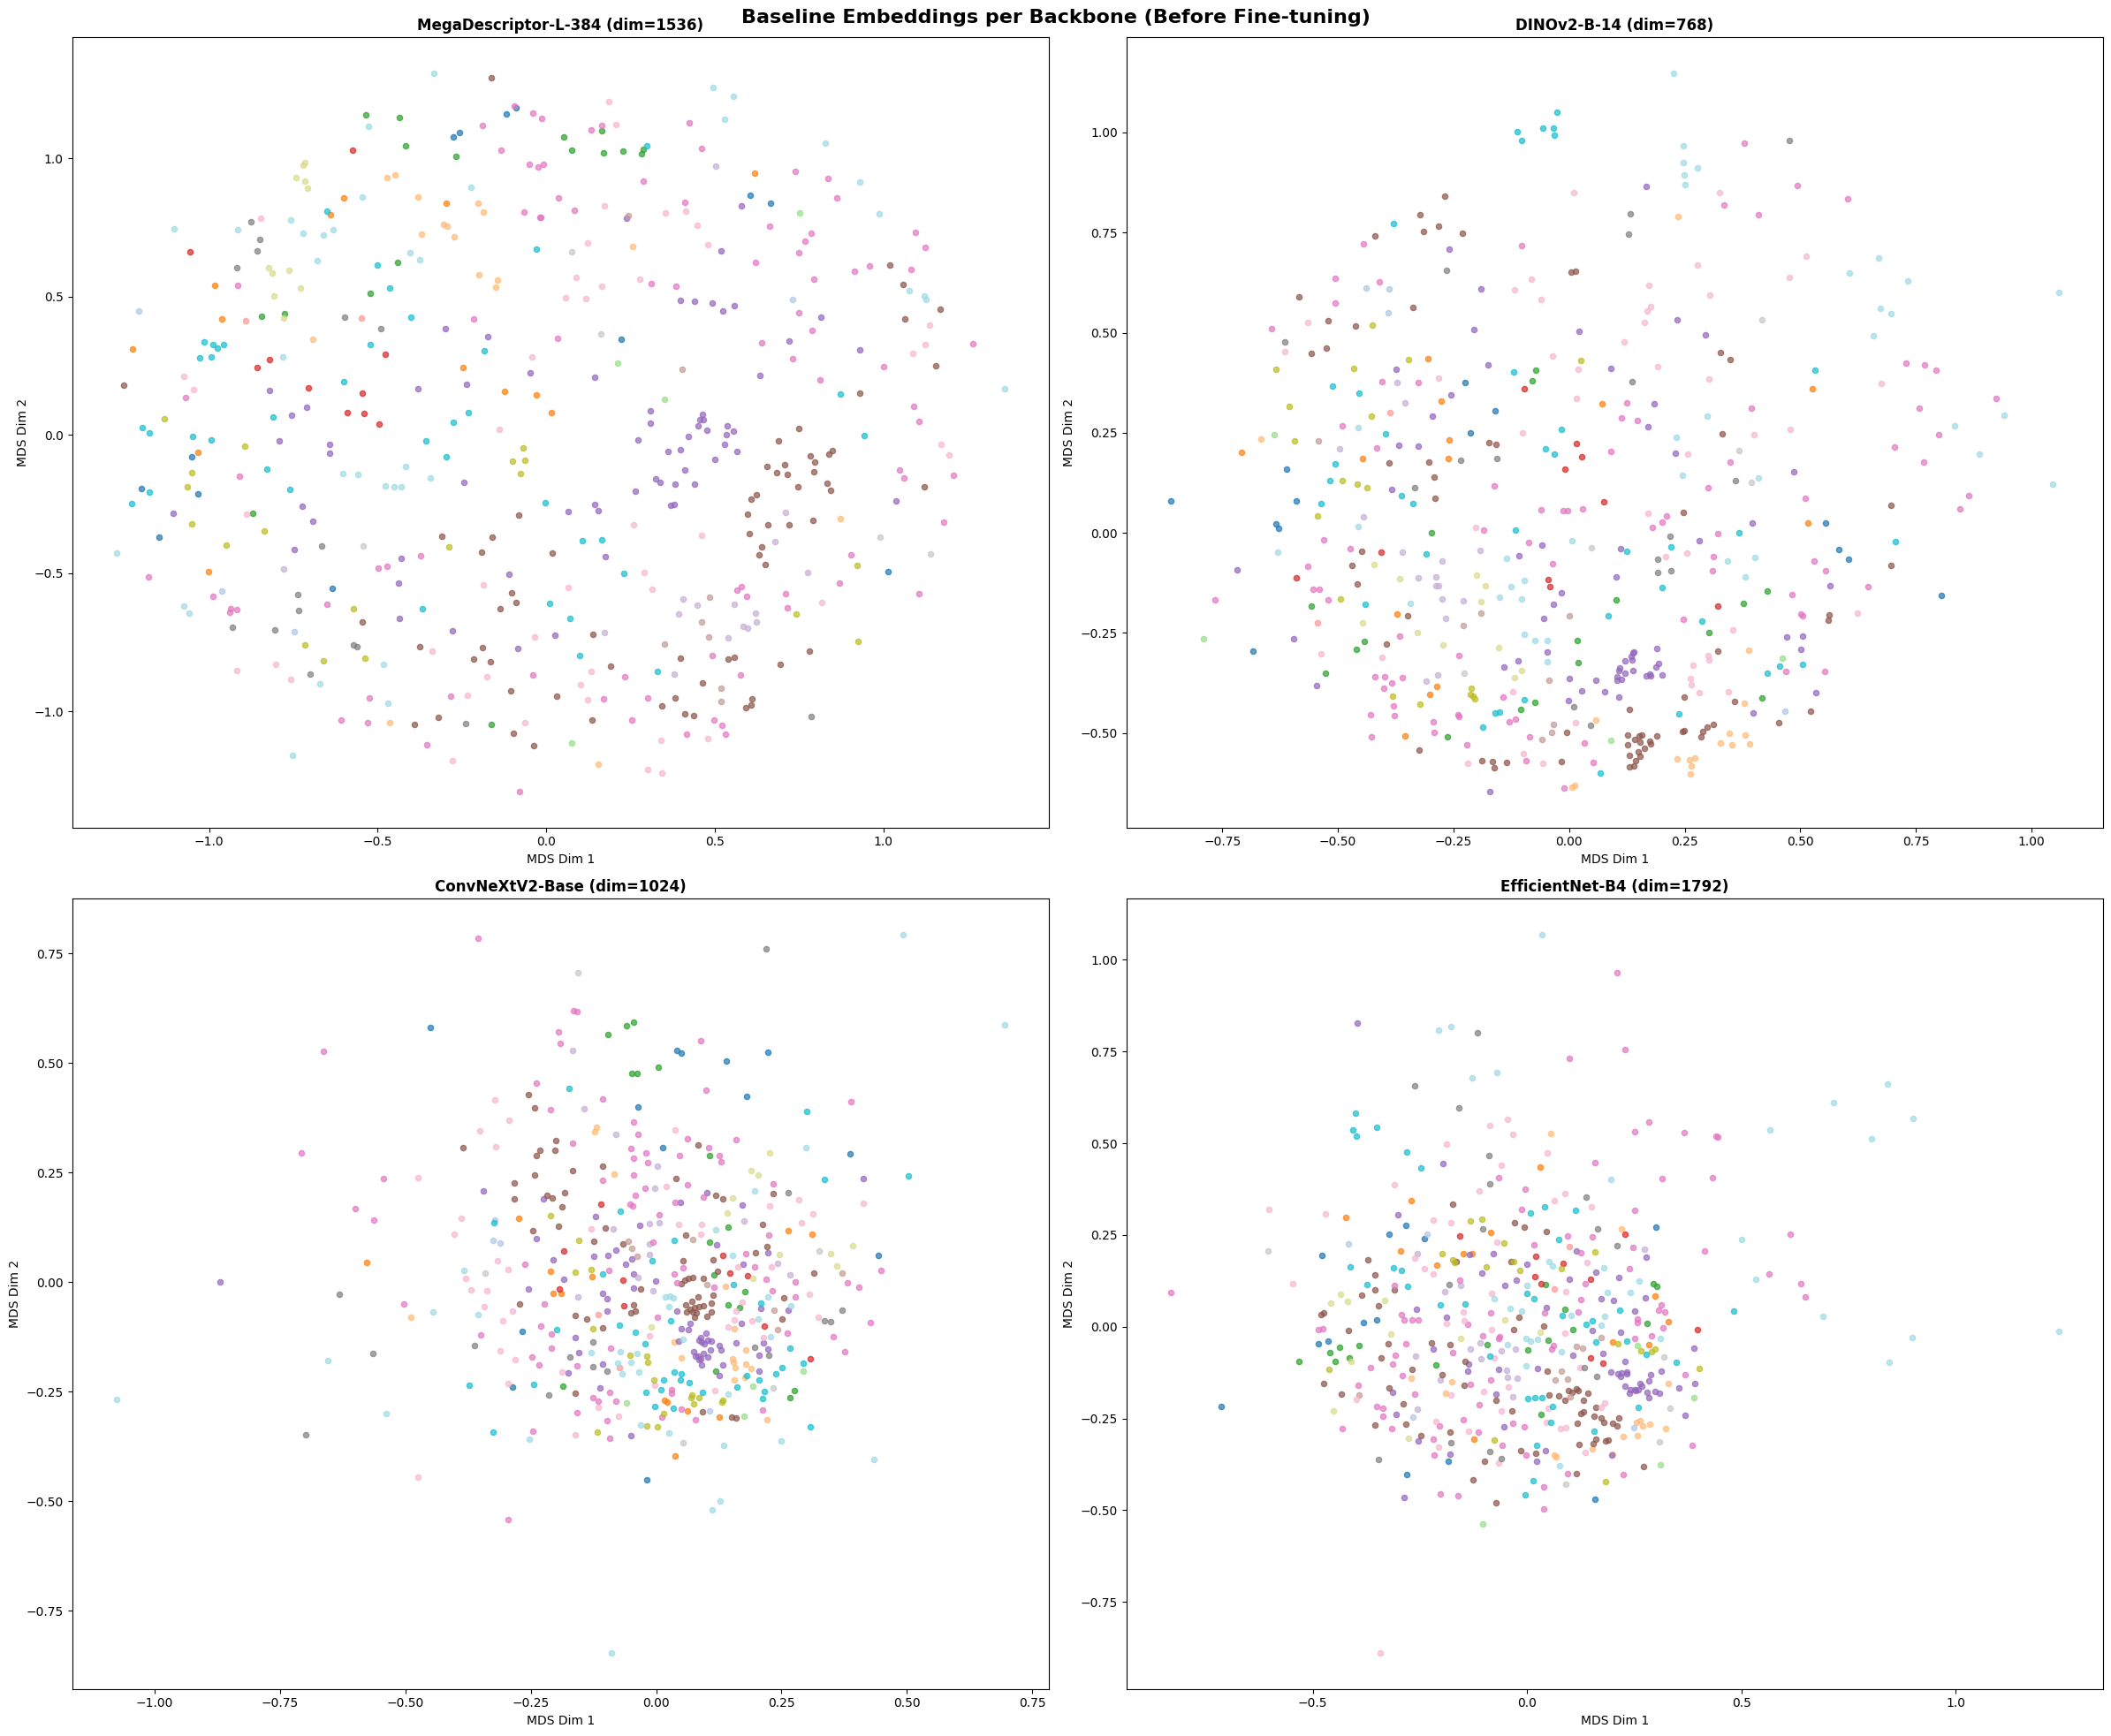

In [8]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    geodesic_dist = np.arccos(cos_sim)
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]

    dist_matrix = compute_geodesic_distances(embeddings)
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)

    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(12, 10))
    for label in unique_labels:
        mask = labels == label
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], c=[label_to_color[label]], label=label, alpha=0.7, s=30)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig


train_labels = train_data['ground_truth'].values

fig, axes = plt.subplots(2, 2, figsize=(24, 20))

for idx, bc in enumerate(BACKBONE_CONFIGS):
    name = bc['name']
    emb = backbone_embeddings[name]['train']

    ax_row, ax_col = idx // 2, idx % 2

    # Subsample for MDS
    max_samples = 500
    if len(emb) > max_samples:
        np.random.seed(RANDOM_SEED)
        sample_idx = np.random.choice(len(emb), max_samples, replace=False)
        emb_sub = emb[sample_idx]
        labels_sub = train_labels[sample_idx]
    else:
        emb_sub = emb
        labels_sub = train_labels

    dist_matrix = compute_geodesic_distances(emb_sub)
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)

    unique_labels = np.unique(labels_sub)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    ax = axes[ax_row, ax_col]
    for label in unique_labels:
        mask = labels_sub == label
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], c=[label_to_color[label]], alpha=0.7, s=20)

    ax.set_title(f'{name} (dim={backbone_embeddings[name]["dim"]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('MDS Dim 1')
    ax.set_ylabel('MDS Dim 2')

plt.suptitle('Baseline Embeddings per Backbone (Before Fine-tuning)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'backbone_baseline_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Define Model Architecture (IDENTICAL to Baseline)

In [9]:
class EmbeddingProjection(nn.Module):
    """Projects backbone embeddings to a lower-dimensional space."""

    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """ArcFace (Additive Angular Margin Loss) layer."""

    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(embeddings, weight_norm).clamp(-1.0, 1.0)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))

        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale
        return output


class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""

    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512,
                 margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout,
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim,
            num_classes=num_classes,
            margin=margin,
            scale=scale,
        )

    def forward(self, x, labels):
        embeddings = self.embedding_net(x)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings

    def get_embeddings(self, x):
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)


print("Model architecture defined (EmbeddingProjection, ArcFaceLayer, ArcFaceModel)")

Model architecture defined (EmbeddingProjection, ArcFaceLayer, ArcFaceModel)


## 6. Training Utilities

In [10]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""

    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


def compute_validation_map(model, val_embeddings, val_labels, device):
    """
    Compute identity-balanced mean Average Precision on validation set.
    IDENTICAL to baseline.
    """
    model.eval()

    with torch.no_grad():
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()

    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)

    query_aps = {}

    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        similarities = sim_matrix[query_idx]

        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0

        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]

        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue

        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives

        query_aps[query_idx] = (query_label, ap)

    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)

    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)

    return balanced_map


def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)

        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings, labels = embeddings.to(device), labels.to(device)

            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training utilities defined")

Training utilities defined


## 7. Backbone Sweep Runner

A generic function that trains an ArcFace model on pre-extracted embeddings from a given backbone and returns results. Each run gets its own W&B run for comparison.

In [11]:
def run_backbone_experiment(
    backbone_name,
    backbone_dim,
    train_embeddings,
    train_labels,
    val_embeddings,
    val_labels_gt,
    val_labels_encoded,
    num_classes,
    device,
    num_epochs=SWEEP_EPOCHS,
    patience=SWEEP_PATIENCE,
):
    """
    Train an ArcFace model on pre-extracted backbone embeddings and return results.

    Args:
        backbone_name: human-readable backbone name (for W&B)
        backbone_dim: dimensionality of backbone embeddings
        train_embeddings: numpy array of training embeddings from this backbone
        train_labels: numpy array of encoded training labels
        val_embeddings: numpy array of validation embeddings from this backbone
        val_labels_gt: numpy array of ground truth validation labels (strings)
        val_labels_encoded: numpy array of encoded validation labels
        num_classes: number of classes
        device: torch device
        num_epochs: number of training epochs
        patience: early stopping patience

    Returns:
        dict with best_val_map, best_val_loss, best_epoch, history
    """
    cfg = base_config

    # Seed for reproducibility
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # W&B config
    wandb_config = {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()}
    wandb_config["backbone_name"] = backbone_name
    wandb_config["backbone_dim"] = backbone_dim

    run = wandb.init(
        project=WANDB_PROJECT,
        group="backbone-comparison",
        config=wandb_config,
        name=f"backbone-{backbone_name}",
        reinit=True,
    )

    # Create model — input_dim adapts to the backbone's embedding dimension
    model = ArcFaceModel(
        input_dim=backbone_dim,
        num_classes=num_classes,
        embedding_dim=cfg["embedding_dim"],
        hidden_dim=cfg["hidden_dim"],
        margin=cfg["arcface_margin"],
        scale=cfg["arcface_scale"],
        dropout=cfg["dropout"],
    ).to(device)

    # Dataloaders
    train_dataset = EmbeddingDataset(train_embeddings, train_labels)
    val_dataset = EmbeddingDataset(val_embeddings, val_labels_encoded)

    train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

    # Loss, optimizer, scheduler (IDENTICAL to baseline)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # Training loop
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': []}
    best_val_loss = float('inf')
    best_map = 0.0
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        val_map = compute_validation_map(model, val_embeddings, val_labels_gt, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss, 'val_acc': val_acc,
            'val_map': val_map, 'learning_rate': current_lr,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    wandb.run.summary["best_val_mAP"] = best_map
    wandb.run.summary["best_val_loss"] = best_val_loss
    wandb.run.summary["best_epoch"] = best_epoch
    wandb.run.summary["total_epochs"] = len(history['train_loss'])
    wandb.run.summary["backbone_dim"] = backbone_dim

    wandb.finish()

    result = {
        "backbone_name": backbone_name,
        "backbone_dim": backbone_dim,
        "best_val_map": best_map,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "total_epochs": len(history['train_loss']),
        "history": history,
    }

    print(f"  [{backbone_name}] Best mAP: {best_map:.4f} (epoch {best_epoch})")
    return result


print("Backbone sweep runner defined")

Backbone sweep runner defined


## 8. Backbone Comparison Sweep

Run each backbone through the same ArcFace training pipeline for 20 epochs.

| Backbone | Params | Embedding Dim | Input Size | Pre-Training |
|----------|--------|---------------|------------|-------------|
| MegaDescriptor-L-384 | ~305M | 1536 | 384 | Wildlife Re-ID |
| DINOv2-B-14 | ~86M | 768 | 518 | Self-supervised (LVD-142M) |
| ConvNeXt V2 Base | ~89M | 1024 | 224 | FCMAE → IN-22k → IN-1k |
| EfficientNet-B4 | ~19M | 1792 | 380 | Supervised (IN-1k) |

In [12]:
# ── Backbone Comparison Sweep ──
print("=" * 70)
print("SWEEP: Backbone Architecture Comparison")
print("=" * 70)

sweep_results = []
for i, bc in enumerate(BACKBONE_CONFIGS):
    name = bc["name"]
    emb_data = backbone_embeddings[name]

    print(f"\n[{i+1}/{len(BACKBONE_CONFIGS)}] Running: {name} (dim={emb_data['dim']})")
    result = run_backbone_experiment(
        backbone_name=name,
        backbone_dim=emb_data["dim"],
        train_embeddings=emb_data["train"],
        train_labels=train_data['label_encoded'].values,
        val_embeddings=emb_data["val"],
        val_labels_gt=val_data['ground_truth'].values,
        val_labels_encoded=val_data['label_encoded'].values,
        num_classes=num_classes,
        device=device,
    )
    sweep_results.append(result)

print("\n" + "=" * 70)
print("SWEEP RESULTS: Backbone Architecture Comparison")
print("-" * 70)
for r in sorted(sweep_results, key=lambda x: x['best_val_map'], reverse=True):
    print(f"  {r['backbone_name']:25s} (dim={r['backbone_dim']:4d}) → mAP: {r['best_val_map']:.4f}  (epoch {r['best_epoch']}/{r['total_epochs']})")

best_backbone = max(sweep_results, key=lambda x: x['best_val_map'])
print(f"\n  ★ Best backbone: {best_backbone['backbone_name']} (mAP: {best_backbone['best_val_map']:.4f})")

SWEEP: Backbone Architecture Comparison

[1/4] Running: MegaDescriptor-L-384 (dim=1536)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_192054-8lc4k7ak
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run backbone-MegaDescriptor-L-384
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/8lc4k7ak
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇███
wandb:      val_loss █▇▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:  backbone_dim 1536
wandb:    be

  [MegaDescriptor-L-384] Best mAP: 0.6716 (epoch 20)

[2/4] Running: DINOv2-B-14 (dim=768)


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_192102-pwkwek9d
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run backbone-DINOv2-B-14
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/pwkwek9d
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▁▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▁▂▃▄▄▅▅▆▆▇▇▇▇█████
wandb:      val_loss █▇▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▄▅▅▆▆▇▇▇▇█████
wandb: 
wandb: Run summary:
wandb:  backbone_dim 768
wandb:    best_epoch 20
wandb: best_val_loss 5.50589
wandb:  best_val_mAP 0.72584
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb

  [DINOv2-B-14] Best mAP: 0.7258 (epoch 20)

[3/4] Running: ConvNeXtV2-Base (dim=1024)


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_192108-27z61a7a
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run backbone-ConvNeXtV2-Base
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/27z61a7a
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇███
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▄▄▅▅▆▆▆▆▇▇▇▇███
wandb:      val_loss █▇▅▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▂▂▃▄▄▅▅▆▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:  backbone_dim 1024
wandb:    best_epoch 20
wandb: best_val_loss 6.67974
wandb:  best_val_mAP 0.71657
wandb:         epoch 20
wandb: learning_rate 0.0001


  [ConvNeXtV2-Base] Best mAP: 0.7166 (epoch 20)

[4/4] Running: EfficientNet-B4 (dim=1792)


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_192114-6yjybwlb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run backbone-EfficientNet-B4
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/6yjybwlb
wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇█████
wandb:      val_loss █▇▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_map ▁▂▂▃▄▄▅▅▅▆▆▇▇▇▇▇████
wandb: 
wandb: Run summary:
wandb:  backbone_dim 1792
wandb:    best_epoch 20
wandb: best_val_loss 6.14586
wandb:  best_val_mAP 0.73498
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 20
wandb:     train_acc 

  [EfficientNet-B4] Best mAP: 0.7350 (epoch 20)

SWEEP RESULTS: Backbone Architecture Comparison
----------------------------------------------------------------------
  EfficientNet-B4           (dim=1792) → mAP: 0.7350  (epoch 20/20)
  DINOv2-B-14               (dim= 768) → mAP: 0.7258  (epoch 20/20)
  ConvNeXtV2-Base           (dim=1024) → mAP: 0.7166  (epoch 20/20)
  MegaDescriptor-L-384      (dim=1536) → mAP: 0.6716  (epoch 20/20)

  ★ Best backbone: EfficientNet-B4 (mAP: 0.7350)


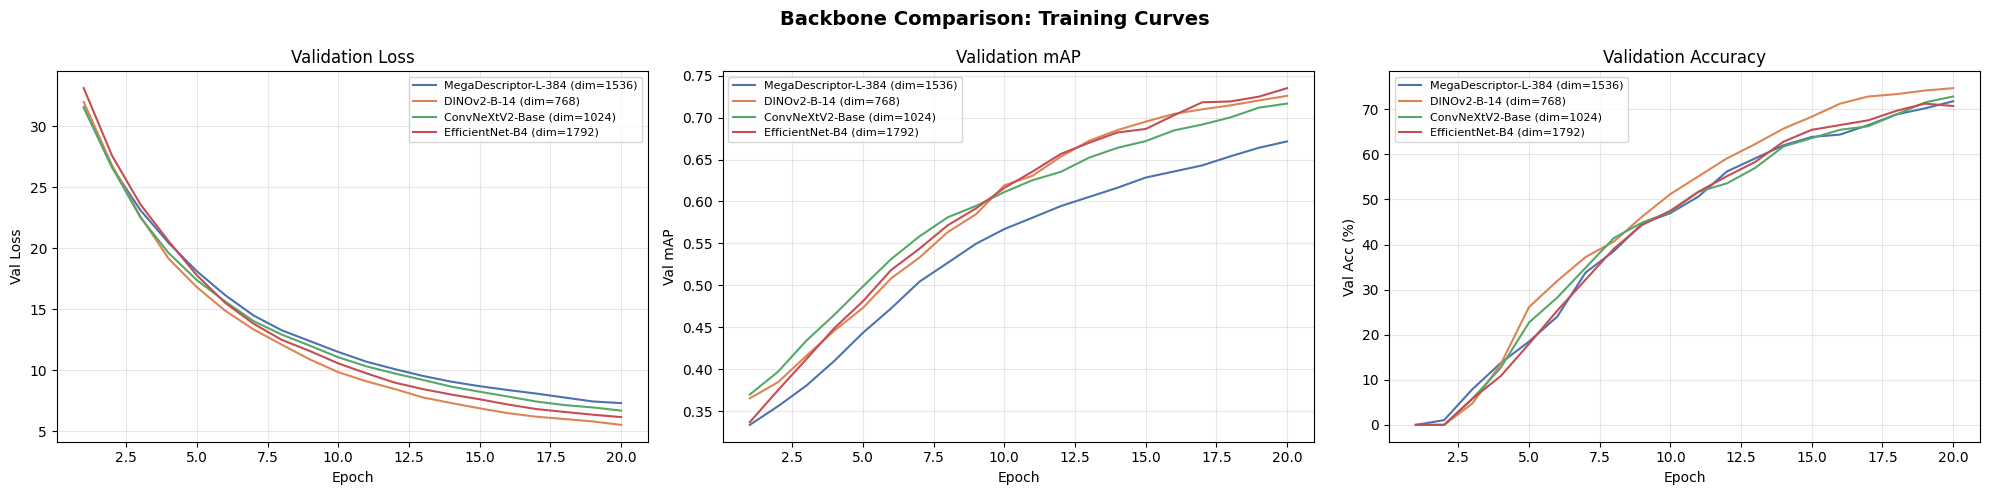

In [13]:
# Visualize sweep results — Training curves comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Backbone Comparison: Training Curves", fontsize=14, fontweight='bold')

backbone_colors = {
    "MegaDescriptor-L-384": "#4C72B0",
    "DINOv2-B-14": "#DD8452",
    "ConvNeXtV2-Base": "#55A868",
    "EfficientNet-B4": "#C44E52",
}

for r in sweep_results:
    label = f"{r['backbone_name']} (dim={r['backbone_dim']})"
    color = backbone_colors.get(r['backbone_name'], 'gray')
    epochs = range(1, len(r['history']['train_loss']) + 1)

    axes[0].plot(epochs, r['history']['val_loss'], label=label, color=color)
    axes[1].plot(epochs, r['history']['val_map'], label=label, color=color)
    axes[2].plot(epochs, r['history']['val_acc'], label=label, color=color)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss'); axes[0].set_title('Validation Loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val mAP'); axes[1].set_title('Validation mAP')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Val Acc (%)'); axes[2].set_title('Validation Accuracy')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'backbone_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

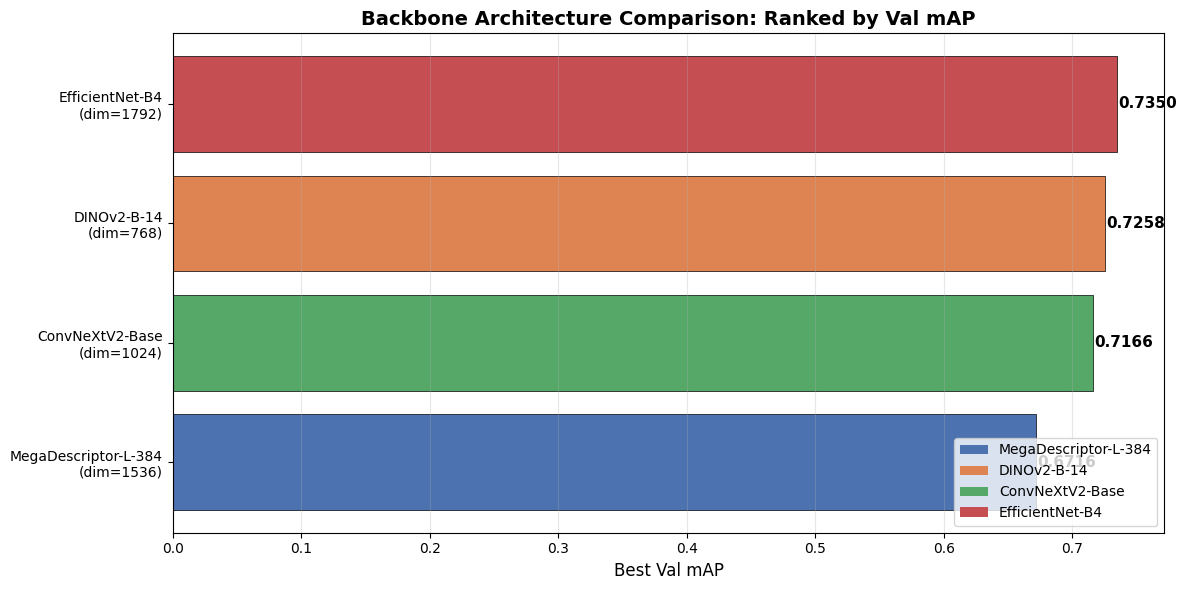

In [14]:
# ── Summary Bar Chart ──
fig, ax = plt.subplots(figsize=(12, 6))

sorted_results = sorted(sweep_results, key=lambda x: x['best_val_map'])
names = [f"{r['backbone_name']}\n(dim={r['backbone_dim']})" for r in sorted_results]
maps = [r['best_val_map'] for r in sorted_results]
colors = [backbone_colors.get(r['backbone_name'], 'gray') for r in sorted_results]

bars = ax.barh(names, maps, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Best Val mAP', fontsize=12)
ax.set_title('Backbone Architecture Comparison: Ranked by Val mAP', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, maps):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

# Legend with architecture details
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=n) for n, c in backbone_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'backbone_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Full Training with Best Backbone

Train the best backbone configuration for the full number of epochs, with checkpointing and submission generation.

In [15]:
# ── Full Training with Best Backbone ──
print("=" * 70)
print("FULL TRAINING: Best Backbone")
print("=" * 70)

best_name = best_backbone['backbone_name']
best_dim = best_backbone['backbone_dim']
best_emb = backbone_embeddings[best_name]

print(f"Backbone: {best_name}")
print(f"Embedding dim: {best_dim}")
print(f"Epochs: {FULL_TRAIN_EPOCHS}")

# Seed
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

cfg = base_config

# W&B run
wandb_config = {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()}
wandb_config["backbone_name"] = best_name
wandb_config["backbone_dim"] = best_dim

run = wandb.init(
    project=WANDB_PROJECT,
    group="backbone-best",
    config=wandb_config,
    name=f"backbone-best-{best_name}",
    reinit=True,
)

# Create model
model = ArcFaceModel(
    input_dim=best_dim,
    num_classes=num_classes,
    embedding_dim=cfg["embedding_dim"],
    hidden_dim=cfg["hidden_dim"],
    margin=cfg["arcface_margin"],
    scale=cfg["arcface_scale"],
    dropout=cfg["dropout"],
).to(device)

# Dataloaders
train_dataset = EmbeddingDataset(best_emb["train"], train_data['label_encoded'].values)
val_dataset = EmbeddingDataset(best_emb["val"], val_data['label_encoded'].values)
train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

FULL TRAINING: Best Backbone
Backbone: EfficientNet-B4
Embedding dim: 1792
Epochs: 50


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_192122-z53vqlx6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run backbone-best-EfficientNet-B4
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/z53vqlx6



Model parameters: 1,058,816


In [16]:
# Full training loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': []}
best_val_loss = float('inf')
best_map = 0.0
patience_counter = 0
best_epoch = 0

print(f"\nStarting full training for {FULL_TRAIN_EPOCHS} epochs...")
print("=" * 70)

for epoch in range(FULL_TRAIN_EPOCHS):
    print(f"\nEpoch {epoch+1}/{FULL_TRAIN_EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    val_map = compute_validation_map(
        model, best_emb["val"], val_data['ground_truth'].values, device
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss, 'val_acc': val_acc,
        'val_map': val_map, 'learning_rate': current_lr,
    })

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
    print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_map = val_map
        best_epoch = epoch + 1
        patience_counter = 0

        checkpoint_path = cfg["checkpoint_dir"] / "best_backbone_model.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_map': val_map,
            'backbone_name': best_name,
            'backbone_dim': best_dim,
            'config': {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()},
            'label_encoder_classes': label_encoder.classes_.tolist(),
            'num_classes': num_classes,
        }, checkpoint_path)
        print(f"  [New best model saved]")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{cfg['patience']}")

    if patience_counter >= cfg['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")

wandb.run.summary["best_val_mAP"] = best_map
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = best_epoch
wandb.run.summary["total_epochs"] = len(history['train_loss'])


Starting full training for 50 epochs...

Epoch 1/50
  Train Loss: 36.7377 | Train Acc: 0.0%
  Val Loss:   33.1397 | Val Acc:   0.0%
  Val mAP:    0.3372 | LR: 1.00e-04
  [New best model saved]

Epoch 2/50
  Train Loss: 31.7415 | Train Acc: 0.0%
  Val Loss:   27.5975 | Val Acc:   0.0%
  Val mAP:    0.3754 | LR: 1.00e-04
  [New best model saved]

Epoch 3/50
  Train Loss: 27.7816 | Train Acc: 0.2%
  Val Loss:   23.6129 | Val Acc:   5.8%
  Val mAP:    0.4122 | LR: 1.00e-04
  [New best model saved]

Epoch 4/50
  Train Loss: 24.4659 | Train Acc: 1.8%
  Val Loss:   20.5816 | Val Acc:   10.8%
  Val mAP:    0.4496 | LR: 1.00e-04
  [New best model saved]

Epoch 5/50
  Train Loss: 21.6614 | Train Acc: 5.1%
  Val Loss:   17.7824 | Val Acc:   17.9%
  Val mAP:    0.4812 | LR: 1.00e-04
  [New best model saved]

Epoch 6/50
  Train Loss: 19.1557 | Train Acc: 8.1%
  Val Loss:   15.5204 | Val Acc:   25.3%
  Val mAP:    0.5185 | LR: 1.00e-04
  [New best model saved]

Epoch 7/50
  Train Loss: 16.8893 | Tr

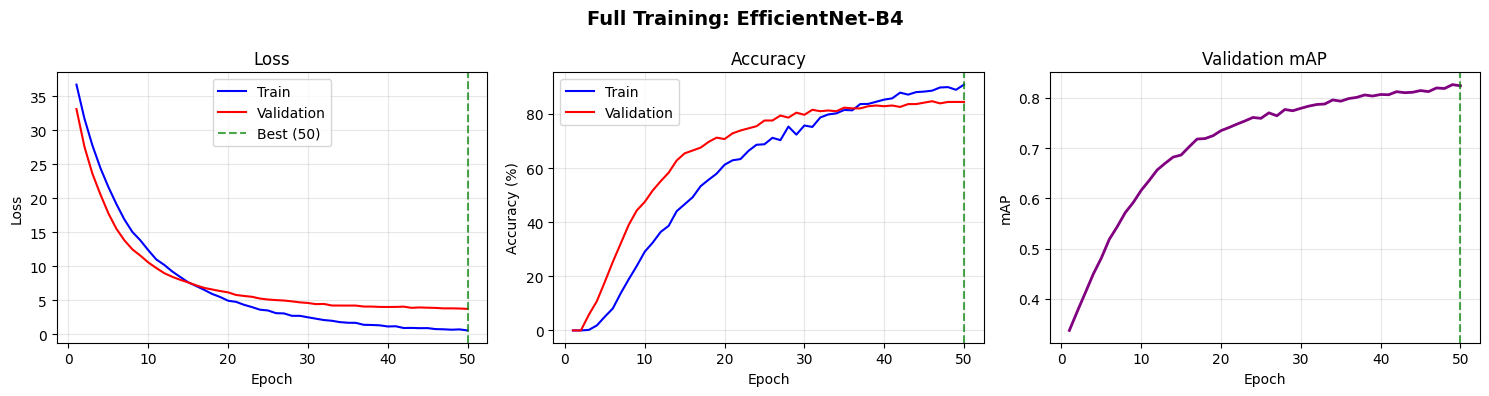

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Full Training: {best_name}", fontsize=14, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('mAP'); axes[2].set_title('Validation mAP')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(cfg["checkpoint_dir"] / 'full_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({"training_curves": wandb.Image(fig)})

## 10. Visualize Fine-tuned Embeddings

In [18]:
# Load best model
checkpoint = torch.load(cfg["checkpoint_dir"] / "best_backbone_model.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Backbone: {checkpoint['backbone_name']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 50
  Backbone: EfficientNet-B4
  Val Loss: 3.7113
  Val mAP: 0.8242


In [19]:
# Extract fine-tuned embeddings
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(best_emb["train"]).to(device)
    finetuned_train_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1516, 256)
Mean L2 norm: 1.0000


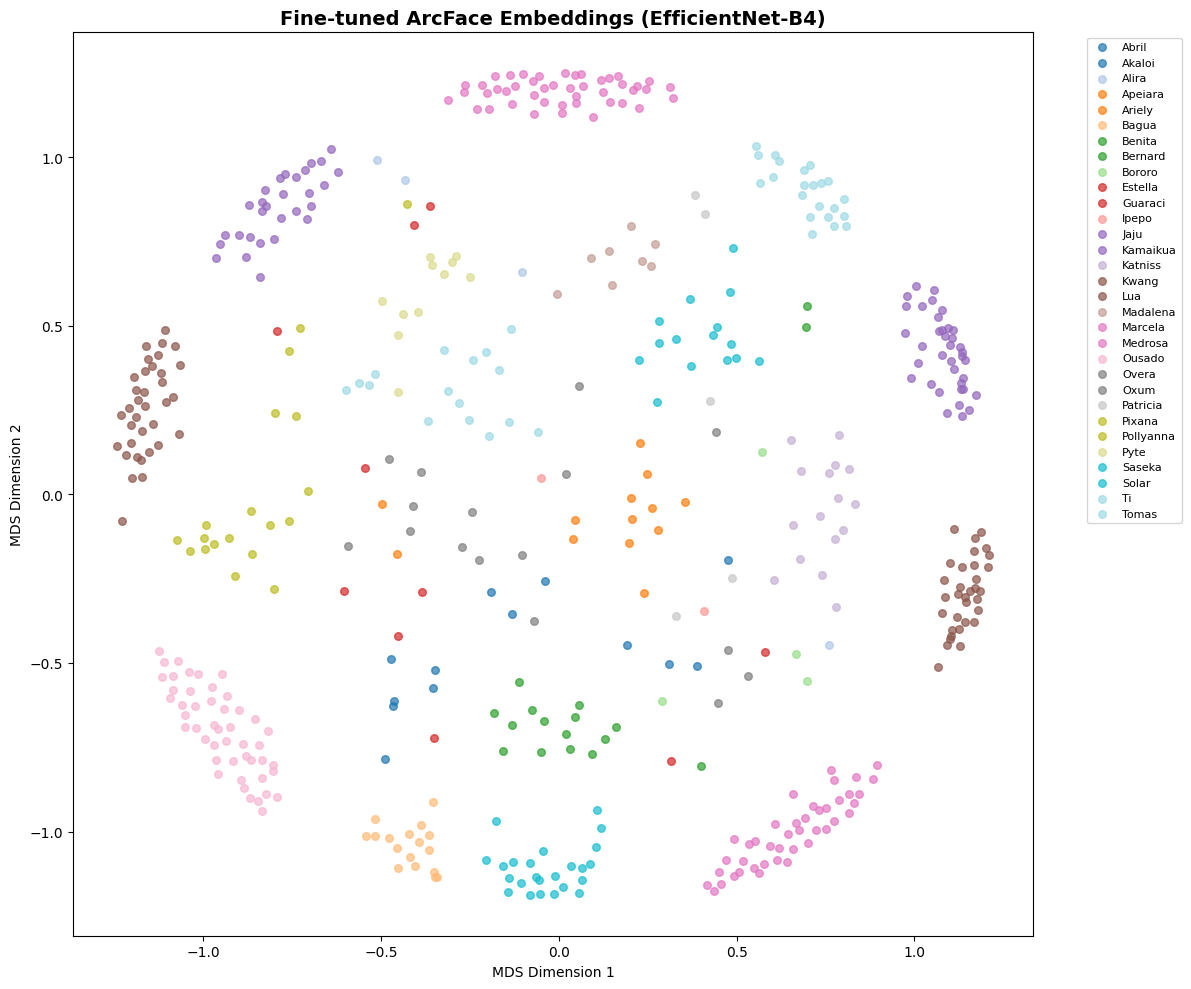

In [20]:
# Visualize fine-tuned embeddings
train_labels = train_data['ground_truth'].values
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings, train_labels,
    f"Fine-tuned ArcFace Embeddings ({best_name})"
)
plt.show()
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

## 11. Generate Competition Submission

In [21]:
# Load test data
test_pairs_df = pd.read_csv(cfg["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [22]:
# Extract test embeddings using the best backbone
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Find the best backbone config to get timm_model and input_size
best_bc = next(bc for bc in BACKBONE_CONFIGS if bc['name'] == best_name)

test_image_paths = [cfg["data_dir"] / "test" / "test" / filename for filename in test_images]

# Load best backbone for test embedding extraction
print(f"\nLoading {best_name} for test embedding extraction...")
test_backbone, _ = load_backbone(best_bc['timm_model'], best_bc['input_size'], device)

print(f"Extracting embeddings for {len(test_images)} test images...")
test_mega_embeddings = extract_embeddings(
    test_backbone, test_image_paths, best_bc['input_size'],
    batch_size=cfg["batch_size"], desc="Test embeddings"
)

# Free backbone from GPU
del test_backbone
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Get fine-tuned test embeddings through projection head
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")

Unique test images: 371

Loading EfficientNet-B4 for test embedding extraction...
  Loading efficientnet_b4.ra2_in1k...
  Loaded successfully:
    Parameters: 17,548,616
    Embedding dim: 1792
    Input size: 380x380
Extracting embeddings for 371 test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Fine-tuned test embeddings shape: (371, 256)


In [23]:
# Compute similarities and create submission
img_to_embedding = {fn: emb for fn, emb in zip(test_images, test_finetuned_embeddings)}

print("Computing pairwise similarities...")
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

# Create submission
submission_df = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
print(f"\nSubmission DataFrame:")
print(submission_df.head(10))

# Verify format
sample_submission = pd.read_csv(cfg["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9903
  Mean: 0.0614
  Std: 0.1274

Submission DataFrame:
   row_id  similarity
0       0    0.502330
1       1    0.028105
2       2    0.140460
3       3    0.147724
4       4    0.029604
5       5    0.263067
6       6    0.000000
7       7    0.000000
8       8    0.126387
9       9    0.000000

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [24]:
# Save submission
submission_path = cfg["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: checkpoints_backbone/submission.csv
File size: 1802.1 KB


## 12. Save Artifacts and Finish

In [25]:
# Save model as W&B artifact
model_artifact = wandb.Artifact(
    name="backbone-experiment-model",
    type="model",
    description=f"Best backbone model ({best_name})"
)
model_artifact.add_file(str(cfg["checkpoint_dir"] / "best_backbone_model.pth"))
wandb.log_artifact(model_artifact)

print("Model artifact saved to W&B")

# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission-backbone-experiment",
    type="submission",
    description=f"Competition submission from backbone experiment ({best_name})"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Model artifact saved to W&B
Submission artifact saved to W&B


In [26]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

wandb: uploading artifact backbone-experiment-model; uploading artifact submission-backbone-experiment; updating run metadata
wandb: uploading artifact backbone-experiment-model; uploading artifact submission-backbone-experiment
wandb: uploading artifact backbone-experiment-model
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
wandb:    train_loss █▇▆▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▁▁▂▂▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇█▇█████████████████
wandb:      val_loss █▇▆▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_map ▁▂▂▃▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
wandb: 
wandb: Run summary:
wandb:    best_epoch 50
wandb: best_val_loss 3.71129
wandb:  best_val_mAP 0.82419
wandb:         epoch 50
wandb: learning_rate 0.0001
wandb:  total_epochs 50
wandb:     train_acc 90.83113
wandb:    train_loss 0.53989
wandb:      

W&B run completed


## Summary

This notebook performed a **systematic comparison of backbone architectures** for jaguar re-identification:

### Backbones Compared
1. **MegaDescriptor-L-384** — ViT-L pre-trained on wildlife re-ID datasets (baseline)
2. **DINOv2-B-14** — ViT-B with self-supervised DINOv2 pre-training on LVD-142M
3. **ConvNeXt V2 Base** — Modern ConvNet with FCMAE pre-training, fine-tuned on ImageNet-22k→1k
4. **EfficientNet-B4** — Compound-scaled CNN with supervised ImageNet pre-training

### Key Differences Between Backbones
- **MegaDescriptor**: Domain-specific (wildlife), ViT architecture, largest model (~305M params)
- **DINOv2**: Self-supervised pre-training produces highly transferable features, ViT architecture
- **ConvNeXt V2**: Modernized ConvNet rivaling ViT, FCMAE self-supervised then supervised fine-tuning
- **EfficientNet**: Smallest model (~19M params), compound-scaled CNN, fully supervised

### Methodology
- All backbones are **frozen** — only the projection head + ArcFace are trained
- Embeddings are extracted once and cached (efficient comparison)
- Each backbone trained for 20 epochs (sweep), best for 50 epochs (full)
- All metrics logged to W&B for comparison

### Controlled Variables
- Same ArcFace loss (margin=0.5, scale=64)
- Same EmbeddingProjection architecture (backbone_dim → 512 → 256)
- Same data (no augmentation)
- Same train/val split (stratified, seed=42)
- Same validation mAP computation
- Same optimizer (AdamW, lr=1e-4) and scheduler (ReduceLROnPlateau)
- Same W&B logging

### How to Compare
- W&B dashboard: filter by group `backbone-comparison` to see all sweep runs
- Compare `best_val_mAP` across runs
- Final model: group `backbone-best`
- Baseline comparison: `megadescriptor-arcface-local` (original baseline)